## Tarea 9: NER
## Nombre: Sergio Trejo
## Matricula: 261539
## Materia: Procesamiento de Lenguaje Natural_A_Presencial_260206


Instrucciones:

1.	Carga el conjunto de datos y revisa su contenido.
2.	Preprocesa los datos para generar las frases tal como las vistas en las diapositivas 19 y 20 de la presentación:
[
 ('Interesante', 'ADJ', 'O'),
 ('será', 'VLfin', 'O'),
 ('conocer', 'VLinf', 'O'),
 ('Pedro', 'NP', 'B-PER'),
 ('Kumamoto', 'NC', 'E-PER')
]

Para lo anterior, considera el siguiente código y, en caso necesario, haz las modificaciones necesarias (no he probado este código):
def agrupar_oraciones(df):
    oraciones = []

    grouped = df.groupby("Sentence #")

    for _, grupo in grouped:
        sentence = [(w, p, t) for w, p, t in zip(grupo["Word"], grupo["Pos"], grupo["Tag"])]
        oraciones.append(sentence)

    return oraciones


sentences = agrupar_oraciones(df)
print(sentences[0])

3.	Genera el conjunto train con el 80% de las frases formadas y el 20% para el conjunto test.
4.	Aplica las métricas para evaluar el desempeño del modelo.
5.	Muestra la matriz de confusión.
6.	Identifica y menciona cuál fue la etiqueta NER que consideres fue en la que CRF tuvo el más bajo desempeño.


Entregables:
•	Script de Python con las implementaciones realizadas (si no desea subir el script, puede copiar y pegar el código y los solicitado en la actividad en un documento de word).


In [17]:
#Librerias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import sklearn_crfsuite
from sklearn_crfsuite import metrics

import matplotlib.pyplot as plt


In [18]:
#cargar conjunto de datos
df = pd.read_csv('split1.mx-news.txt',sep='\t', encoding='utf-8')
print(df.head())

   Sentence #         Word    Pos Tag
0  Sentence 1  Interesante    ADJ   O
1  Sentence 1         será  VLfin   O
2  Sentence 1      conocer  VLinf   O
3  Sentence 1          las    ART   O
4  Sentence 1  reflexiones     NC   O


In [19]:
#Agrupar las palabras por oracion
def agrupar_oraciones(df):
    oraciones = []

    grouped = df.groupby('Sentence #')
    
    for _, group in grouped:
        sentence = [(w, p, t) for w, p, t in zip(group['Word'], group['Pos'], group['Tag'])]
        oraciones.append(sentence)
    return oraciones

sentences = agrupar_oraciones(df)

print(sentences[0])

[('Interesante', 'ADJ', 'O'), ('será', 'VLfin', 'O'), ('conocer', 'VLinf', 'O'), ('las', 'ART', 'O'), ('reflexiones', 'NC', 'O'), ('de', 'PREP', 'O'), ('Pedro', 'NP', 'B-PER'), ('Kumamoto', 'NC', 'E-PER'), ('en', 'PREP', 'O'), ('torno', 'NC', 'O'), ('a', 'PREP', 'O'), ('este', 'DM', 'O'), ('fracaso', 'NC', 'O'), (',', 'CM', 'O'), ('por', 'PREP', 'O'), ('el', 'ART', 'O'), ('momento', 'NC', 'O'), ('lo', 'ART', 'O'), ('único', 'NC', 'O'), ('que', 'CQUE', 'O'), ('ha', 'VHfin', 'O'), ('dicho', 'QU', 'O'), ('es', 'VSfin', 'O'), ('que', 'CQUE', 'O'), ('al', 'PAL', 'O'), ('interior', 'NC', 'O'), ('de', 'PREP', 'O'), ('su', 'PPO', 'O'), ('grupo', 'NC', 'O'), ('existen', 'VLfin', 'O'), ('dos', 'CARD', 'O'), ('planteamientos', 'NC', 'O'), (',', 'CM', 'O'), ('uno', 'CARD', 'O'), ('seguir', 'VLinf', 'O'), ('por', 'PREP', 'O'), ('la', 'ART', 'O'), ('ruta', 'NC', 'O'), ('independiente', 'ADJ', 'O'), (',', 'CM', 'O'), ('el', 'ART', 'O'), ('otro', 'QU', 'O'), ('destaca', 'VLfin', 'O'), ('las', 'ART', '

In [20]:
#Definicion de caracteristicas
def word2features(sentence, i):
    word = sentence[i][0]
    pos = sentence[i][1]

    features = {
        'word': word,
        'pos': pos,
        'is_upper': word.isupper(),
        'is_title': word.istitle(),
        'is_digit': word.isdigit()
    }

    if i > 0:
        prev_word = sentence[i-1][0]
        prev_pos = sentence[i-1][1]
        features.update({
            '-1:word': prev_word,
            '-1:pos': prev_pos
        })
    else:
        features['BOS'] = True

    if i < len(sentence)-1:
        next_word = sentence[i+1][0]
        next_pos = sentence[i+1][1]
        features.update({
            '+1:word': next_word,
            '+1:pos': next_pos
        })
    else:
        features['EOS'] = True

    return features

In [21]:
#Convercion de oraciones a caracteristicas
def sentence2features(sentence):
    return [word2features(sentence, i) for i in range(len(sentence))]

def sentence2labels(sentence):
    return [label for _, _, label in sentence]

In [22]:
#Preparacion de las variables X, y y division del conjunto de entrenamiento (80%) y prueba (20%)
X = [sentence2features(s) for s in sentences]
y = [sentence2labels(s) for s in sentences]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [23]:
#Entrenamiento del modelo CRF
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    max_iterations=100,
)

crf.fit(X_train, y_train)

,algorithm,'lbfgs'
,min_freq,None
,all_possible_states,None
,all_possible_transitions,None
,c1,None
,c2,None
,max_iterations,100
,num_memories,None
,epsilon,None
,period,None
,delta,None


              precision    recall  f1-score   support

       B-ADD      0.857     0.462     0.600        13
       B-AGE      1.000     0.400     0.571         5
       B-DAT      0.902     0.925     0.914        80
       B-DOC      1.000     0.500     0.667        12
       B-EVT      0.667     0.286     0.400        21
       B-FAC      0.875     0.583     0.700        12
       B-GPE      0.842     0.516     0.640        31
       B-LOC      0.000     0.000     0.000         1
       B-MNY      1.000     0.786     0.880        14
       B-ORG      0.721     0.759     0.739        58
       B-PER      0.821     0.856     0.838       139
       B-PEX      1.000     0.700     0.824        10
       B-PRC      1.000     1.000     1.000         8
       B-PRO      0.000     0.000     0.000         2
       B-TIM      0.976     0.952     0.964        42
       B-TIT      0.738     0.633     0.681        49
       E-ADD      0.857     0.462     0.600        13
       E-AGE      1.000    

/home/sergioai/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sergioai/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sergioai/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

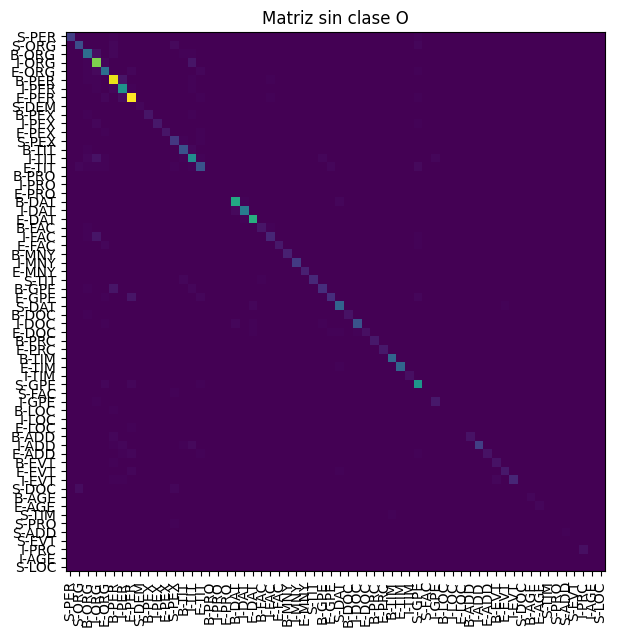

In [33]:
#Evaluacion del modelo y matriz de confusion
y_pred = crf.predict(X_test)
print(metrics.flat_classification_report(y_test, y_pred, digits=3))

labels = list(crf.classes_)

# APLANAR (esto es la clave)
y_test_flat = [item for sublist in y_test for item in sublist]
y_pred_flat = [item for sublist in y_pred for item in sublist]

labels_filtered = [l for l in labels if l != 'O']

cm = confusion_matrix(y_test_flat, y_pred_flat, labels=labels_filtered)

plt.figure(figsize=(10, 7))
plt.imshow(cm)

plt.title('Matriz sin clase O')
plt.xticks(np.arange(len(labels_filtered)), labels_filtered, rotation=90)
plt.yticks(np.arange(len(labels_filtered)), labels_filtered)

plt.show()

## Conclusion De Resultados

* La etiqueta con menor desempeño fue B-LOC y B-PRO, ya que presentan valores de precision, recall y f1-score iguales a 0. Esto indica que el modelo no logro identificar correctamente ninguna instancia de estas entidades durante la evaluacion, lo cual refleja una limitacion en su capacidad para generalizar en estas clases.

* Este comportamiento se explica principalmente por la baja cantidad de ejemplos disponibles en el dataset para estas etiquetas, lo que impide que el modelo aprenda patrones representativos. En problemas de NER, esto es comun cuando existen clases poco frecuentes, ya que el modelo tiende a priorizar aquellas con mayor presencia.

* Por otro lado, las etiquetas mas frecuentes como B-PER, B-DAT y B-TIM muestran un desempeño alto en precision y recall, lo que indica que el modelo logra aprender correctamente las caracteristicas de estas entidades. Esto confirma que el CRF funciona mejor cuando cuenta con suficiente informacion para entrenar.

* En la matriz de confusion se observa una concentracion de valores en la diagonal principal, lo que indica que la mayoria de las predicciones son correctas. Sin embargo, tambien se identifican algunos valores fuera de la diagonal, lo que refleja confusiones entre ciertas etiquetas, especialmente en aquellas con menor representacion, lo cual impacta el promedio general del modelo.
